In [29]:
!pip install tabulate

In [3]:
import numpy as np
import pandas as pd

import japanize_matplotlib
import matplotlib.pyplot as plt

## 演習問題4.1

In [4]:
# 表4.5の作成
df_45 = pd.DataFrame(
    {
        "year": [1984, 1985, 1986, 1987, 1988],
        "四半期_1": [1, 27, 43, 88, 110],
        "四半期_2": [6, 39, 51, 97, 113],
        "四半期_3": [16, 31, 63, 91, 149],
        "四半期_4": [23, 30, 70, 104, 159],
    }
)

## (a)

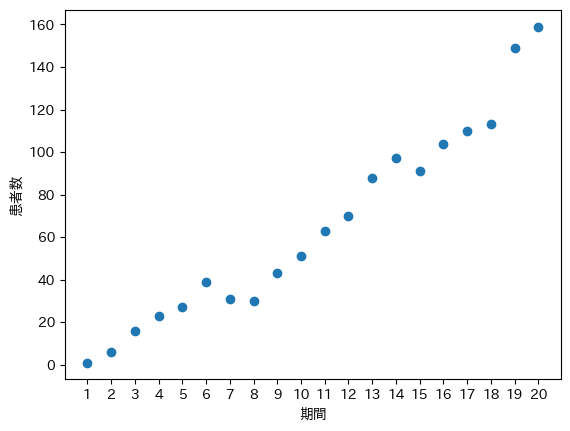

In [26]:
array_45 = df_45.drop(["year"], axis=1).values.reshape(-1)

plt.scatter(list(range(1, len(array_45) + 1)), array_45)

plt.xlabel("期間")  # x軸ラベル
plt.ylabel("患者数")  # y軸ラベル

plt.xticks(range(1, len(array_45) + 1))

plt.savefig("4_1_a.png")

plt.show()

## (b)

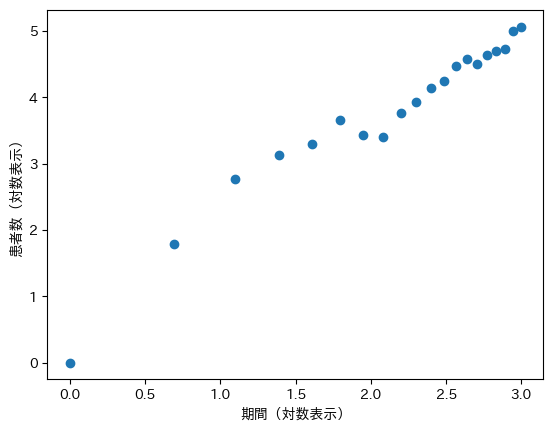

In [27]:
plt.scatter(np.log(list(range(1, len(array_45) + 1))), np.log(array_45))

plt.xlabel("期間（対数表示）")  # x軸ラベル
plt.ylabel("患者数（対数表示）")  # y軸ラベル
plt.savefig("4_1_b.png")
plt.show()

## (c)

In [15]:
X = np.stack(
    (np.ones(len(array_45)), np.log(list(range(1, len(array_45) + 1)))), axis=1
)

y = array_45.copy()

# パラメータの初期値
beta = np.ones(X.shape[1])
n_iters = 10

list_beta = []
for t in range(n_iters):
    eta_t = X @ beta
    lambda_t = np.exp(eta_t)
    z_t = eta_t + (y - lambda_t) / lambda_t
    W_t = np.diag(lambda_t)
    beta = np.linalg.inv((X.T) @ W_t @ X) @ (X.T) @ W_t @ z_t
    list_beta.append(beta)

In [31]:
print(pd.DataFrame(list_beta, columns=["beta_0", "beta_1"]).to_markdown())

|    |   beta_0 |   beta_1 |
|---:|---------:|---------:|
|  0 | 0.652354 |  1.65199 |
|  1 | 0.841857 |  1.42955 |
|  2 | 0.98454  |  1.33373 |
|  3 | 0.995952 |  1.32664 |
|  4 | 0.995998 |  1.32661 |
|  5 | 0.995998 |  1.32661 |
|  6 | 0.995998 |  1.32661 |
|  7 | 0.995998 |  1.32661 |
|  8 | 0.995998 |  1.32661 |
|  9 | 0.995998 |  1.32661 |


## (d)

In [18]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [19]:
data = pd.DataFrame(np.stack((X[:, 1], y), axis=1), columns=["x", "y"])
model = smf.glm(formula="y ~ x", data=data, family=sm.families.Poisson())
result = model.fit()

In [33]:
print(
    pd.DataFrame(
        result.params.values.reshape(1, 2), columns=["beta_0", "beta_1"]
    ).to_markdown()
)

|    |   beta_0 |   beta_1 |
|---:|---------:|---------:|
|  0 | 0.995998 |  1.32661 |
